# 07 — Synthetic Degradation Dataset Generation

This notebook generates controlled synthetic visual degradations for a fixed five-painting subset.

The experiment extends the canonical binary-damage datasets with surface-like and appearance-based degradations:

- blur;
- water-like staining;
- fading;
- discolouration;
- dirt and dust;
- partial transparency.

Each single degradation is generated at three severity levels:

- mild;
- moderate;
- severe.

The notebook also generates selected combined degradations:

- fading with discolouration;
- water-like staining with dirt;
- blur with fading.

Effect masks are stored separately from degradation operators. Each case retains the clean reference, deterministic seeds, complete operator parameters, checksums, and validation metadata.

## Canonical experiment size

- 5 paintings
- 6 single degradation families
- 3 severity levels
- 3 combined degradation families
- 90 single-effect cases
- 15 combined cases
- 105 total cases

These outputs are controlled visual simulations for evaluation research. They are not physically complete models of material ageing, chemical deterioration, pigment transport, varnish behaviour, or conservation damage.

In [1]:
from pathlib import Path
import sys


def find_project_root(
    start_path: Path,
) -> Path:
    required_paths = (
        Path("config")
        / "experiment_50_config.yaml",
        Path("src")
        / "restoration_eval",
        Path("notebooks"),
    )

    candidate = (
        start_path.resolve()
    )

    for possible_root in (
        candidate,
        *candidate.parents,
    ):
        if all(
            (
                possible_root
                / required_path
            ).exists()
            for required_path in required_paths
        ):
            return possible_root

    raise RuntimeError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

required_files = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml",
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "synthetic_degradation.py",
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
    / "metadata_processed_clean.csv",
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
    / "metadata_damage_size_sensitivity.csv",
)

missing_required_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_required_files:
    raise FileNotFoundError(
        "Notebook 07 environment gate failed. "
        f"Missing files: {missing_required_files}"
    )

print(
    "Notebook 07 environment gate passed."
)

print(
    "Project root:",
    PROJECT_ROOT,
)

Notebook 07 environment gate passed.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
import json
import shutil
from datetime import (
    datetime,
    timezone,
)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image

from restoration_eval.synthetic_degradation import (
    DEFAULT_COMBINED_DEGRADATIONS,
    DEFAULT_DEGRADATION_TYPES,
    DEFAULT_SEVERITY_LEVELS,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    audit_synthetic_degradation_inventory,
    create_synthetic_degradation_dataset,
    validate_synthetic_degradation_dataset,
)


config_path = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)

with config_path.open(
    "r",
    encoding="utf-8",
) as config_file:
    experiment_config = yaml.safe_load(
        config_file
    )

if (
    "synthetic_degradation"
    not in experiment_config
):
    raise KeyError(
        "Missing synthetic_degradation "
        "configuration section."
    )

synthetic_config = (
    experiment_config[
        "synthetic_degradation"
    ]
)

processed_metadata_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
    / "metadata_processed_clean.csv"
)

reference_subset_metadata_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
    / "metadata_damage_size_sensitivity.csv"
)

synthetic_metadata_path = (
    PROJECT_ROOT
    / synthetic_config[
        "metadata_path"
    ]
)

effect_mask_dir = (
    PROJECT_ROOT
    / synthetic_config[
        "effect_mask_dir"
    ]
)

degraded_dir = (
    PROJECT_ROOT
    / synthetic_config[
        "degraded_dir"
    ]
)

outputs_dir = (
    PROJECT_ROOT
    / synthetic_config[
        "outputs_dir"
    ]
)

metrics_dir = (
    outputs_dir
    / "metrics"
)

figures_dir = (
    outputs_dir
    / "figures"
)

temporary_test_dir = (
    outputs_dir
    / "_test"
)

temporary_test_mask_dir = (
    temporary_test_dir
    / "effect_masks"
)

temporary_test_degraded_dir = (
    temporary_test_dir
    / "degraded"
)

for directory in (
    synthetic_metadata_path.parent,
    effect_mask_dir,
    degraded_dir,
    outputs_dir,
    metrics_dir,
    figures_dir,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

degradation_types = tuple(
    synthetic_config.get(
        "degradation_types",
        DEFAULT_DEGRADATION_TYPES,
    )
)

severity_levels = tuple(
    synthetic_config.get(
        "severity_levels",
        DEFAULT_SEVERITY_LEVELS,
    )
)

combined_config = (
    synthetic_config.get(
        "combined_degradations",
        DEFAULT_COMBINED_DEGRADATIONS,
    )
)

if isinstance(
    combined_config,
    list,
):
    combined_degradations = {
        name: (
            DEFAULT_COMBINED_DEGRADATIONS[
                name
            ]
        )
        for name in combined_config
    }
else:
    combined_degradations = {
        str(name): tuple(
            components
        )
        for name, components
        in combined_config.items()
    }

combined_severity = str(
    synthetic_config.get(
        "combined_severity",
        "moderate",
    )
)

expected_painting_count = int(
    synthetic_config.get(
        "expected_painting_count",
        5,
    )
)

global_seed = int(
    synthetic_config.get(
        "global_seed",
        20260707,
    )
)

target_size = int(
    synthetic_config.get(
        "target_size",
        768,
    )
)

expected_single_case_count = (
    expected_painting_count
    * len(
        degradation_types
    )
    * len(
        severity_levels
    )
)

expected_combined_case_count = (
    expected_painting_count
    * len(
        combined_degradations
    )
)

expected_case_count = (
    expected_single_case_count
    + expected_combined_case_count
)

if degradation_types != tuple(
    DEFAULT_DEGRADATION_TYPES
):
    raise ValueError(
        "Canonical degradation families differ "
        "from the expected six-family design."
    )

if severity_levels != tuple(
    DEFAULT_SEVERITY_LEVELS
):
    raise ValueError(
        "Canonical severity levels differ from "
        "the expected mild/moderate/severe design."
    )

if expected_case_count != 105:
    raise ValueError(
        "Canonical experiment must contain "
        f"105 cases, observed expectation "
        f"is {expected_case_count}."
    )

print(
    "Generator:",
    GENERATOR_NAME,
    GENERATOR_VERSION,
)

print(
    "Expected single-effect cases:",
    expected_single_case_count,
)

print(
    "Expected combined cases:",
    expected_combined_case_count,
)

print(
    "Expected full cases:",
    expected_case_count,
)

Generator: synthetic_degradation 1.0.0
Expected single-effect cases: 90
Expected combined cases: 15
Expected full cases: 105


In [3]:
processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

reference_subset_metadata_df = pd.read_csv(
    reference_subset_metadata_path
)

required_processed_columns = {
    "painting_id",
}

missing_processed_columns = sorted(
    required_processed_columns
    - set(
        processed_metadata_df.columns
    )
)

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing "
        f"required columns: "
        f"{missing_processed_columns}"
    )

if (
    "painting_id"
    not in reference_subset_metadata_df.columns
):
    raise ValueError(
        "Reference subset metadata does not "
        "contain painting_id."
    )

canonical_painting_ids = (
    reference_subset_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .drop_duplicates()
    .tolist()
)

if (
    len(
        canonical_painting_ids
    )
    != expected_painting_count
):
    raise ValueError(
        "Reference subset contains the wrong "
        "number of paintings: "
        f"observed={len(canonical_painting_ids)}, "
        f"expected={expected_painting_count}"
    )

processed_metadata_df[
    "painting_id"
] = (
    processed_metadata_df[
        "painting_id"
    ].astype(str)
)

synthetic_processed_metadata_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ].isin(
            canonical_painting_ids
        )
    ]
    .copy()
)

painting_order = {
    painting_id: index
    for index, painting_id
    in enumerate(
        canonical_painting_ids
    )
}

synthetic_processed_metadata_df[
    "_canonical_order"
] = (
    synthetic_processed_metadata_df[
        "painting_id"
    ].map(
        painting_order
    )
)

synthetic_processed_metadata_df = (
    synthetic_processed_metadata_df
    .sort_values(
        "_canonical_order",
        kind="stable",
    )
    .drop(
        columns=[
            "_canonical_order"
        ]
    )
    .reset_index(drop=True)
)

if (
    len(
        synthetic_processed_metadata_df
    )
    != expected_painting_count
):
    raise ValueError(
        "Processed metadata did not resolve "
        "exactly one row per canonical painting."
    )

if (
    synthetic_processed_metadata_df[
        "painting_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Canonical painting subset contains "
        "duplicate painting IDs."
    )

resolved_painting_ids = (
    synthetic_processed_metadata_df[
        "painting_id"
    ]
    .tolist()
)

if (
    resolved_painting_ids
    != canonical_painting_ids
):
    raise ValueError(
        "Resolved painting order does not match "
        "the canonical Notebook 05 subset."
    )

path_columns = [
    column
    for column in (
        "processed_path",
        "clean_path",
        "image_path",
        "processed_image_path",
    )
    if column
    in synthetic_processed_metadata_df.columns
]

if not path_columns:
    raise ValueError(
        "No clean-image path column was found."
    )

clean_path_column = (
    path_columns[0]
)

subset_gate_records = []

for _, row in (
    synthetic_processed_metadata_df.iterrows()
):
    clean_path = Path(
        row[
            clean_path_column
        ]
    )

    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )

    image_exists = (
        clean_path.exists()
    )
    image_readable = False
    dimensions_valid = False

    if image_exists:
        try:
            with Image.open(
                clean_path
            ) as image:
                image.load()
                image_readable = True
                dimensions_valid = (
                    image.size
                    == (
                        target_size,
                        target_size,
                    )
                )
        except Exception:
            image_readable = False

    subset_gate_records.append(
        {
            "painting_id": (
                row["painting_id"]
            ),
            "clean_path": str(
                clean_path
            ),
            "image_exists": (
                image_exists
            ),
            "image_readable": (
                image_readable
            ),
            "dimensions_valid": (
                dimensions_valid
            ),
        }
    )

subset_gate_df = pd.DataFrame(
    subset_gate_records
)

display(
    synthetic_processed_metadata_df[
        [
            column
            for column in (
                "painting_id",
                "title",
                "artist",
                "style_group",
                "category",
                clean_path_column,
            )
            if column
            in synthetic_processed_metadata_df.columns
        ]
    ]
)

display(
    subset_gate_df
)

if not bool(
    subset_gate_df[
        [
            "image_exists",
            "image_readable",
            "dimensions_valid",
        ]
    ].all().all()
):
    raise ValueError(
        "Canonical five-painting subset gate failed."
    )

print(
    "Canonical five-painting subset passed."
)

,painting_id,title,artist,category,processed_path
0,p001,Juan de Pareja,Diego Velázquez,portrait_figure,data/processed/clean/p001_clean.png
1,p018,Classical Landscape with Figures,Henri Mauperché,landscape_natural,data/processed/clean/p018_clean.png
2,p026,View of a Village along a River,attributed to Jan Brueghel I,architecture_structured,data/processed/clean/p026_clean.png
3,p039,Painting with Troika,Wassily Kandinsky,abstraction_surrealism,data/processed/clean/p039_clean.png
4,p043,The Card Players,Paul Cézanne,high_texture_brushwork,data/processed/clean/p043_clean.png


,painting_id,clean_path,image_exists,image_readable,dimensions_valid
0,p001,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,True
1,p018,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,True
2,p026,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,True
3,p039,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,True
4,p043,D:\Masters\FH\Thesis\painting-restoration-eval...,True,True,True


Canonical five-painting subset passed.


In [4]:
expected_case_records = []

for painting_id in canonical_painting_ids:
    for degradation_type in (
        degradation_types
    ):
        for severity in (
            severity_levels
        ):
            case_id = (
                f"{painting_id}"
                f"__{degradation_type}"
                f"__{severity}"
            )

            expected_case_records.append(
                {
                    "case_id": case_id,
                    "painting_id": (
                        painting_id
                    ),
                    "degradation_type": (
                        degradation_type
                    ),
                    "severity": severity,
                    "is_combined": False,
                    "component_degradations": (
                        degradation_type
                    ),
                    "expected_effect_mask_filename": (
                        f"{case_id}"
                        "_effect_mask.png"
                    ),
                    "expected_degraded_filename": (
                        f"{case_id}"
                        "_degraded.png"
                    ),
                }
            )

    for (
        combined_name,
        components,
    ) in combined_degradations.items():
        case_id = (
            f"{painting_id}"
            f"__{combined_name}"
            f"__{combined_severity}"
        )

        expected_case_records.append(
            {
                "case_id": case_id,
                "painting_id": (
                    painting_id
                ),
                "degradation_type": (
                    combined_name
                ),
                "severity": (
                    combined_severity
                ),
                "is_combined": True,
                "component_degradations": (
                    "|".join(
                        components
                    )
                ),
                "expected_effect_mask_filename": (
                    f"{case_id}"
                    "_effect_mask.png"
                ),
                "expected_degraded_filename": (
                    f"{case_id}"
                    "_degraded.png"
                ),
            }
        )

expected_case_manifest_df = pd.DataFrame(
    expected_case_records
)

if (
    len(
        expected_case_manifest_df
    )
    != expected_case_count
):
    raise ValueError(
        "Expected manifest contains the wrong "
        "number of cases."
    )

if (
    expected_case_manifest_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Expected manifest contains duplicate "
        "case IDs."
    )

manifest_summary_df = pd.DataFrame(
    [
        {
            "measure": "paintings",
            "value": (
                expected_case_manifest_df[
                    "painting_id"
                ]
                .nunique()
            ),
        },
        {
            "measure": "single_cases",
            "value": int(
                (
                    ~expected_case_manifest_df[
                        "is_combined"
                    ]
                ).sum()
            ),
        },
        {
            "measure": "combined_cases",
            "value": int(
                expected_case_manifest_df[
                    "is_combined"
                ].sum()
            ),
        },
        {
            "measure": "total_cases",
            "value": len(
                expected_case_manifest_df
            ),
        },
    ]
)

family_manifest_summary_df = (
    expected_case_manifest_df
    .groupby(
        [
            "is_combined",
            "degradation_type",
            "severity",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(
    manifest_summary_df
)

display(
    family_manifest_summary_df
)

print(
    "Expected synthetic-degradation "
    "manifest passed."
)

,measure,value
0,paintings,5
1,single_cases,90
2,combined_cases,15
3,total_cases,105


,is_combined,degradation_type,severity,case_count,painting_count
0,False,blur,mild,5,5
1,False,blur,moderate,5,5
2,False,blur,severe,5,5
3,False,dirt_dust,mild,5,5
4,False,dirt_dust,moderate,5,5
5,False,dirt_dust,severe,5,5
6,False,discolouration,mild,5,5
7,False,discolouration,moderate,5,5
8,False,discolouration,severe,5,5
9,False,fading,mild,5,5


Expected synthetic-degradation manifest passed.


In [5]:
example_painting_df = (
    synthetic_processed_metadata_df
    .iloc[[0]]
    .copy()
)

example_painting_id = str(
    example_painting_df.iloc[0][
        "painting_id"
    ]
)

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )

temporary_test_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_test_degraded_dir.mkdir(
    parents=True,
    exist_ok=True,
)

example_degradation_df = (
    create_synthetic_degradation_dataset(
        processed_metadata=(
            example_painting_df
        ),
        output_effect_mask_dir=(
            temporary_test_mask_dir
        ),
        output_degraded_dir=(
            temporary_test_degraded_dir
        ),
        project_root=PROJECT_ROOT,
        degradation_types=(
            degradation_types
        ),
        severity_levels=(
            "moderate",
        ),
        combined_degradations={},
        combined_severity=(
            combined_severity
        ),
        target_size=target_size,
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

expected_example_case_count = len(
    degradation_types
)

if (
    len(
        example_degradation_df
    )
    != expected_example_case_count
):
    raise ValueError(
        "Example generation produced the wrong "
        "number of cases: "
        f"observed={len(example_degradation_df)}, "
        f"expected={expected_example_case_count}"
    )

if (
    example_degradation_df[
        "degradation_type"
    ].nunique()
    != expected_example_case_count
):
    raise ValueError(
        "Example generation did not produce "
        "all six degradation families."
    )

display_columns = [
    column
    for column in (
        "case_id",
        "painting_id",
        "degradation_type",
        "severity",
        "effect_active_pixels",
        "effect_percentage_content",
        "effect_mean_intensity",
        "changed_pixels",
        "outside_effect_changed_pixels",
        "mean_absolute_difference_effect",
        "generation_action",
    )
    if column
    in example_degradation_df.columns
]

display(
    example_degradation_df[
        display_columns
    ]
)

print(
    "Generated example cases:",
    len(
        example_degradation_df
    ),
)

print(
    "Example painting:",
    example_painting_id,
)

,case_id,painting_id,degradation_type,severity,effect_active_pixels,effect_percentage_content,effect_mean_intensity,changed_pixels,outside_effect_changed_pixels,mean_absolute_difference_effect,generation_action
0,p001__blur__moderate,p001,blur,moderate,214399,42.106390,111.966852,133112,0,0.675684,generated
1,p001__dirt_dust__moderate,p001,dirt_dust,moderate,84027,16.502286,56.130851,5147,0,0.030635,generated
2,p001__discolouration__moderate,p001,discolouration,moderate,158262,31.081495,126.182748,129332,0,1.267382,generated
3,p001__fading__moderate,p001,fading,moderate,163657,32.141033,117.209811,145201,0,1.185240,generated
4,p001__partial_transparency__moderate,p001,partial_transparency,moderate,203183,39.903650,119.014824,231901,0,11.983279,generated
5,p001__water_stain__moderate,p001,water_stain,moderate,112727,22.138755,95.782927,119265,0,5.146515,generated


Generated example cases: 6
Example painting: p001


In [6]:
example_validation_df = (
    validate_synthetic_degradation_dataset(
        degradation_metadata=(
            example_degradation_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)

example_validation_summary_df = (
    example_validation_df[
        [
            "degradation_type",
            "severity",
            "effect_nonempty",
            "degradation_nonempty",
            "outside_effect_preserved",
            "metadata_counts_match",
            "checksum_valid",
            "validation_passed",
            "issue",
        ]
    ]
)

display(
    example_validation_summary_df
)

failed_example_validation_df = (
    example_validation_df[
        ~example_validation_df[
            "validation_passed"
        ]
    ]
)

if not failed_example_validation_df.empty:
    display(
        failed_example_validation_df
    )

    raise ValueError(
        "Example synthetic-degradation "
        "validation failed."
    )

print(
    "All six example degradations passed "
    "validation."
)

,degradation_type,severity,effect_nonempty,degradation_nonempty,outside_effect_preserved,metadata_counts_match,checksum_valid,validation_passed,issue
0,blur,moderate,True,True,True,True,True,True,
1,dirt_dust,moderate,True,True,True,True,True,True,
2,discolouration,moderate,True,True,True,True,True,True,
3,fading,moderate,True,True,True,True,True,True,
4,partial_transparency,moderate,True,True,True,True,True,True,
5,water_stain,moderate,True,True,True,True,True,True,


All six example degradations passed validation.


In [7]:
example_parameter_records = []

for _, row in (
    example_degradation_df.iterrows()
):
    parameter_groups = json.loads(
        row[
            "operator_parameters_json"
        ]
    )

    for component_index, parameters in enumerate(
        parameter_groups
    ):
        parameter_record = {
            "case_id": row[
                "case_id"
            ],
            "degradation_type": row[
                "degradation_type"
            ],
            "severity": row[
                "severity"
            ],
            "component_index": int(
                component_index
            ),
            "component_degradation": (
                parameters.get(
                    "degradation_type"
                )
            ),
            "operator_seed": (
                parameters.get(
                    "seed"
                )
            ),
        }

        for key, value in (
            parameters.items()
        ):
            if key not in {
                "degradation_type",
                "seed",
            }:
                parameter_record[
                    key
                ] = value

        example_parameter_records.append(
            parameter_record
        )

example_parameters_df = pd.DataFrame(
    example_parameter_records
)

display(
    example_parameters_df
)

if (
    example_parameters_df[
        "operator_seed"
    ].isna().any()
):
    raise ValueError(
        "One or more example operators are "
        "missing deterministic seeds."
    )

if (
    example_parameters_df[
        "operator_seed"
    ].duplicated().any()
):
    raise ValueError(
        "Example operator seeds are not unique."
    )

print(
    "Example operator-parameter audit passed."
)

,case_id,degradation_type,severity,component_index,component_degradation,operator_seed,blur_radius,effect_opacity,grime_strength,particle_count_estimate,...,channel_scale_g,channel_scale_r,brightness_factor,contrast_factor,saturation_factor,substrate_colour_rgb,transparency_alpha,ring_strength,stain_colour_rgb,stain_opacity
0,p001__blur__moderate,blur,moderate,0,blur,2214173340,3.0,0.75,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,p001__dirt_dust__moderate,dirt_dust,moderate,0,dirt_dust,175732196,NaN,NaN,0.1,7071.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,p001__discolouration__moderate,discolouration,moderate,0,discolouration,147221102,NaN,NaN,NaN,NaN,...,0.97,1.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p001__fading__moderate,fading,moderate,0,fading,3888891329,NaN,NaN,NaN,NaN,...,NaN,NaN,1.07,0.86,0.62,NaN,NaN,NaN,NaN,NaN
4,p001__partial_transparency__moderate,partial_transparency,moderate,0,partial_transparency,4004581363,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"[196, 178, 145]",0.24,NaN,NaN,NaN
5,p001__water_stain__moderate,water_stain,moderate,0,water_stain,421443941,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.28,"[132, 91, 45]",0.28


Example operator-parameter audit passed.


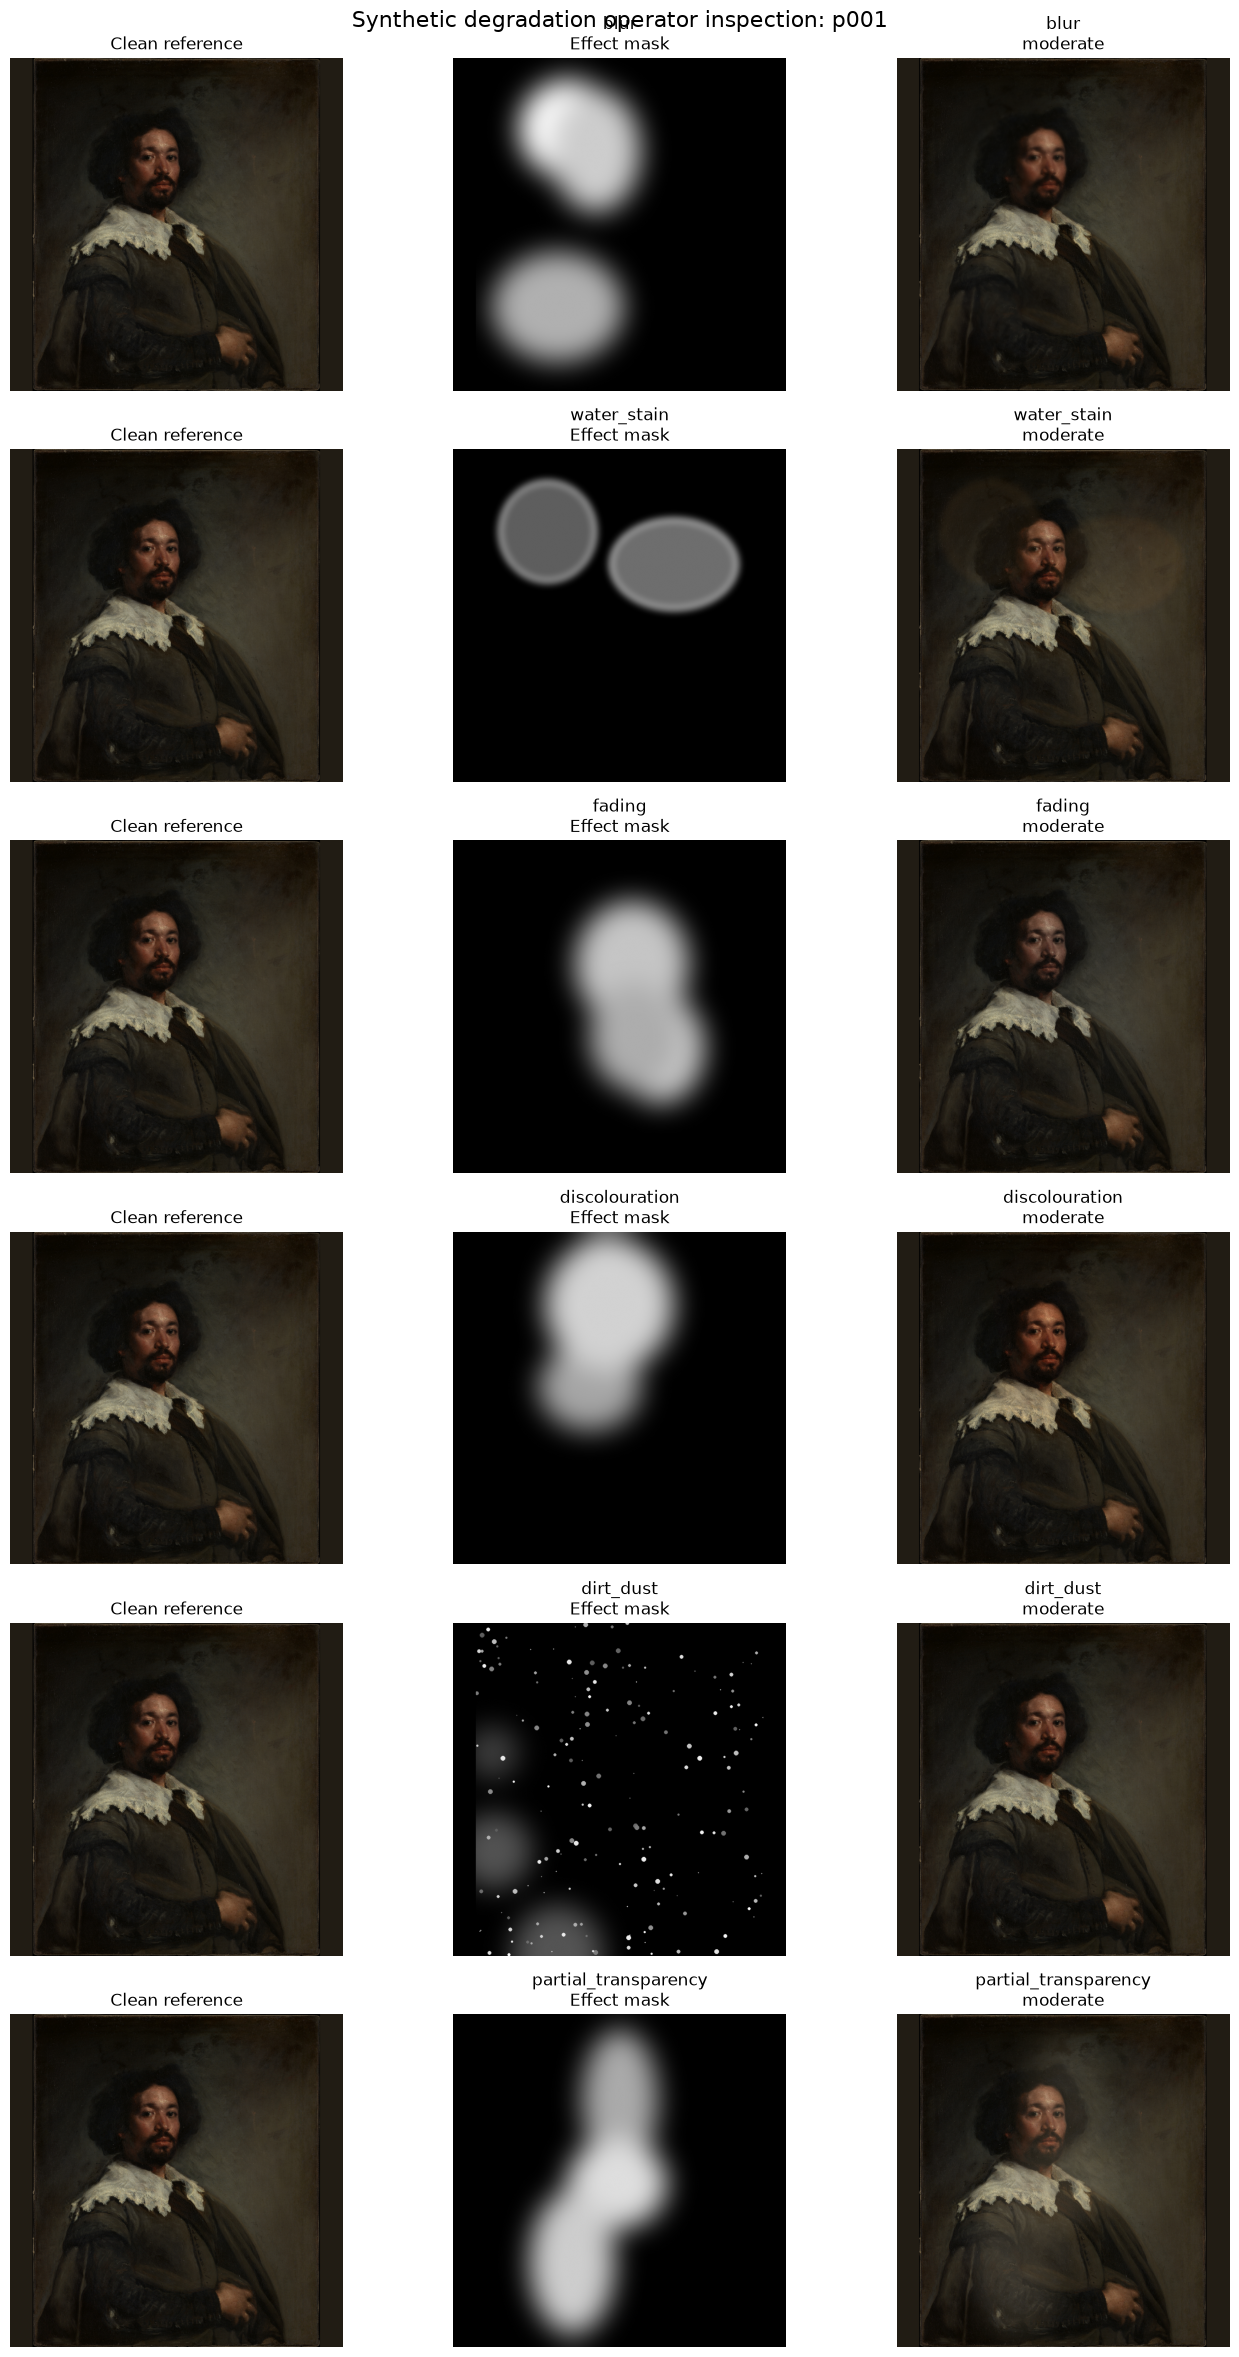

Saved example figure: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\figures\p001__operator_inspection.png


In [8]:
def resolve_project_path(
    path_value,
) -> Path:
    path = Path(
        path_value
    )

    if not path.is_absolute():
        path = (
            PROJECT_ROOT
            / path
        )

    return path


example_clean_path = (
    resolve_project_path(
        example_degradation_df.iloc[0][
            "clean_path"
        ]
    )
)

with Image.open(
    example_clean_path
) as clean_image_file:
    example_clean_image = (
        clean_image_file
        .convert("RGB")
        .copy()
    )

ordered_example_df = (
    example_degradation_df
    .set_index(
        "degradation_type"
    )
    .loc[
        list(
            degradation_types
        )
    ]
    .reset_index()
)

figure, axes = plt.subplots(
    nrows=len(
        degradation_types
    ),
    ncols=3,
    figsize=(
        14,
        4
        * len(
            degradation_types
        ),
    ),
)

for row_index, row in (
    ordered_example_df.iterrows()
):
    effect_mask_path = (
        resolve_project_path(
            row[
                "effect_mask_path"
            ]
        )
    )
    degraded_path = (
        resolve_project_path(
            row[
                "degraded_path"
            ]
        )
    )

    with Image.open(
        effect_mask_path
    ) as effect_mask_file:
        effect_mask_image = (
            effect_mask_file
            .convert("L")
            .copy()
        )

    with Image.open(
        degraded_path
    ) as degraded_image_file:
        degraded_image = (
            degraded_image_file
            .convert("RGB")
            .copy()
        )

    axes[
        row_index,
        0,
    ].imshow(
        example_clean_image
    )

    axes[
        row_index,
        0,
    ].set_title(
        "Clean reference"
    )

    axes[
        row_index,
        1,
    ].imshow(
        effect_mask_image,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        row_index,
        1,
    ].set_title(
        (
            f"{row['degradation_type']}\n"
            "Effect mask"
        )
    )

    axes[
        row_index,
        2,
    ].imshow(
        degraded_image
    )

    axes[
        row_index,
        2,
    ].set_title(
        (
            f"{row['degradation_type']}\n"
            f"{row['severity']}"
        )
    )

    for column_index in range(
        3
    ):
        axes[
            row_index,
            column_index,
        ].axis(
            "off"
        )

figure.suptitle(
    (
        "Synthetic degradation operator "
        f"inspection: {example_painting_id}"
    ),
    fontsize=16,
)

figure.tight_layout()

example_figure_path = (
    figures_dir
    / (
        f"{example_painting_id}"
        "__operator_inspection.png"
    )
)

figure.savefig(
    example_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved example figure:",
    example_figure_path,
)

In [9]:
example_combined_name = (
    "fading_discolouration"
)

if (
    example_combined_name
    not in combined_degradations
):
    raise KeyError(
        "Missing canonical combined degradation: "
        f"{example_combined_name}"
    )

example_combined_mask_dir = (
    temporary_test_dir
    / "combined_effect_masks"
)

example_combined_degraded_dir = (
    temporary_test_dir
    / "combined_degraded"
)

if example_combined_mask_dir.exists():
    shutil.rmtree(
        example_combined_mask_dir
    )

if example_combined_degraded_dir.exists():
    shutil.rmtree(
        example_combined_degraded_dir
    )

example_combined_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

example_combined_degraded_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# The current module requires at least one
# single degradation type. Generate one
# disposable fading case alongside the
# combined case, then retain only the
# combined row.
example_combined_generation_df = (
    create_synthetic_degradation_dataset(
        processed_metadata=(
            example_painting_df
        ),
        output_effect_mask_dir=(
            example_combined_mask_dir
        ),
        output_degraded_dir=(
            example_combined_degraded_dir
        ),
        project_root=PROJECT_ROOT,
        degradation_types=(
            "fading",
        ),
        severity_levels=(
            combined_severity,
        ),
        combined_degradations={
            example_combined_name: (
                combined_degradations[
                    example_combined_name
                ]
            )
        },
        combined_severity=(
            combined_severity
        ),
        target_size=target_size,
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

example_combined_df = (
    example_combined_generation_df[
        example_combined_generation_df[
            "is_combined"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

if len(
    example_combined_generation_df
) != 2:
    raise ValueError(
        "Combined checkpoint should generate "
        "one disposable single case and one "
        "combined case."
    )

if len(
    example_combined_df
) != 1:
    raise ValueError(
        "Expected exactly one combined "
        "degradation example."
    )

example_combined_validation_df = (
    validate_synthetic_degradation_dataset(
        degradation_metadata=(
            example_combined_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)

display(
    example_combined_df[
        [
            "case_id",
            "painting_id",
            "degradation_type",
            "severity",
            "is_combined",
            "component_degradations",
            "component_count",
            "effect_active_pixels",
            "effect_percentage_content",
            "changed_pixels",
            "outside_effect_changed_pixels",
            "mean_absolute_difference_effect",
        ]
    ]
)

display(
    example_combined_validation_df[
        [
            "case_id",
            "effect_nonempty",
            "degradation_nonempty",
            "outside_effect_preserved",
            "metadata_counts_match",
            "checksum_valid",
            "validation_passed",
            "issue",
        ]
    ]
)

if not bool(
    example_combined_validation_df[
        "validation_passed"
    ].all()
):
    raise ValueError(
        "Combined degradation example "
        "validation failed."
    )

combined_parameters = json.loads(
    example_combined_df.iloc[0][
        "operator_parameters_json"
    ]
)

if len(
    combined_parameters
) != 2:
    raise ValueError(
        "Combined example does not contain "
        "exactly two operator parameter "
        "records."
    )

observed_components = {
    parameter[
        "degradation_type"
    ]
    for parameter in combined_parameters
}

expected_components = set(
    combined_degradations[
        example_combined_name
    ]
)

if (
    observed_components
    != expected_components
):
    raise ValueError(
        "Combined example components do not "
        "match the configured components."
    )

combined_operator_seeds = [
    int(
        parameter[
            "seed"
        ]
    )
    for parameter in combined_parameters
]

if (
    len(
        combined_operator_seeds
    )
    != len(
        set(
            combined_operator_seeds
        )
    )
):
    raise ValueError(
        "Combined operator seeds are not unique."
    )

print(
    "Combined degradation example passed."
)

print(
    "Components:",
    sorted(
        observed_components
    ),
)

,case_id,painting_id,degradation_type,severity,is_combined,component_degradations,component_count,effect_active_pixels,effect_percentage_content,changed_pixels,outside_effect_changed_pixels,mean_absolute_difference_effect
0,p001__fading_discolouration__moderate,p001,fading_discolouration,moderate,True,fading|discolouration,2,200931,39.461373,170056,0,0.705074


,case_id,effect_nonempty,degradation_nonempty,outside_effect_preserved,metadata_counts_match,checksum_valid,validation_passed,issue
0,p001__fading_discolouration__moderate,True,True,True,True,True,True,


Combined degradation example passed.
Components: ['discolouration', 'fading']


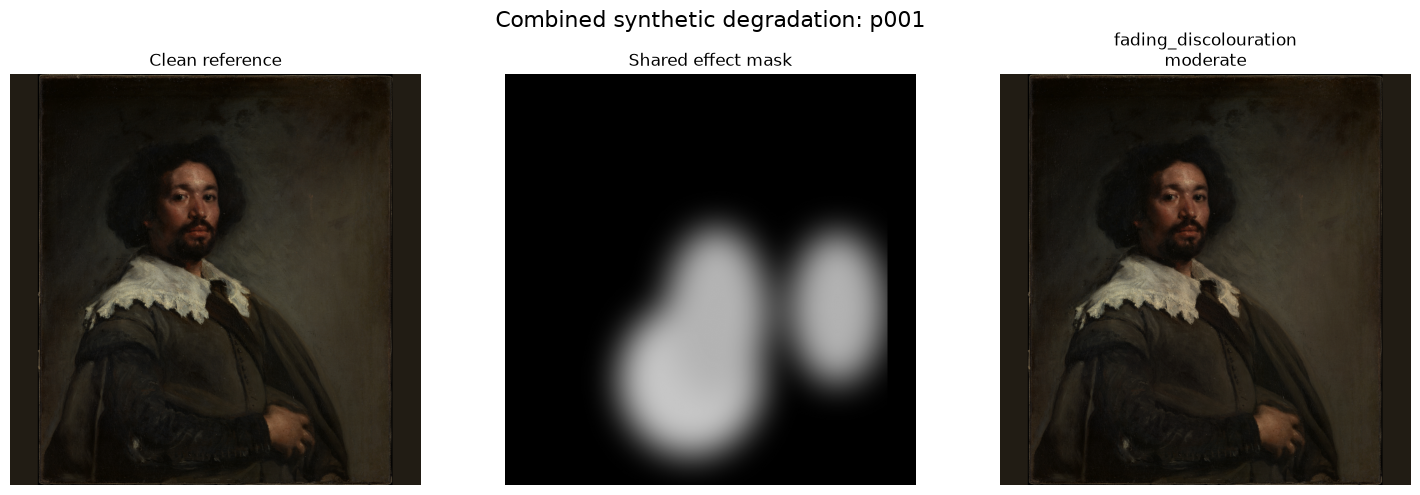

Saved combined example figure: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\figures\p001__fading_discolouration__inspection.png


In [10]:
combined_example_row = (
    example_combined_df.iloc[0]
)

combined_clean_path = (
    resolve_project_path(
        combined_example_row[
            "clean_path"
        ]
    )
)

combined_effect_mask_path = (
    resolve_project_path(
        combined_example_row[
            "effect_mask_path"
        ]
    )
)

combined_degraded_path = (
    resolve_project_path(
        combined_example_row[
            "degraded_path"
        ]
    )
)

with Image.open(
    combined_clean_path
) as image:
    combined_clean_image = (
        image.convert("RGB").copy()
    )

with Image.open(
    combined_effect_mask_path
) as image:
    combined_effect_mask_image = (
        image.convert("L").copy()
    )

with Image.open(
    combined_degraded_path
) as image:
    combined_degraded_image = (
        image.convert("RGB").copy()
    )

figure, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(
        15,
        5,
    ),
)

axes[0].imshow(
    combined_clean_image
)
axes[0].set_title(
    "Clean reference"
)

axes[1].imshow(
    combined_effect_mask_image,
    cmap="gray",
    vmin=0,
    vmax=255,
)
axes[1].set_title(
    "Shared effect mask"
)

axes[2].imshow(
    combined_degraded_image
)
axes[2].set_title(
    (
        f"{example_combined_name}\n"
        f"{combined_severity}"
    )
)

for axis in axes:
    axis.axis(
        "off"
    )

figure.suptitle(
    (
        "Combined synthetic degradation: "
        f"{example_painting_id}"
    ),
    fontsize=16,
)

figure.tight_layout()

combined_example_figure_path = (
    figures_dir
    / (
        f"{example_painting_id}"
        f"__{example_combined_name}"
        "__inspection.png"
    )
)

figure.savefig(
    combined_example_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved combined example figure:",
    combined_example_figure_path,
)

In [11]:
canonical_suffixes = (
    "_effect_mask.png",
    "_degraded.png",
)

removed_file_records = []

for directory, suffix in (
    (
        effect_mask_dir,
        canonical_suffixes[0],
    ),
    (
        degraded_dir,
        canonical_suffixes[1],
    ),
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    for path in directory.glob(
        f"*{suffix}"
    ):
        if not path.is_file():
            continue

        removed_file_records.append(
            {
                "directory": str(
                    directory
                ),
                "filename": path.name,
            }
        )

        path.unlink()

removed_files_df = pd.DataFrame(
    removed_file_records
)

if not removed_files_df.empty:
    display(
        removed_files_df.head(
            20
        )
    )

print(
    "Removed canonical files:",
    len(
        removed_file_records
    ),
)

print(
    "Canonical output directories are ready."
)

Removed canonical files: 0
Canonical output directories are ready.


In [12]:
synthetic_degradation_df = (
    create_synthetic_degradation_dataset(
        processed_metadata=(
            synthetic_processed_metadata_df
        ),
        output_effect_mask_dir=(
            effect_mask_dir
        ),
        output_degraded_dir=(
            degraded_dir
        ),
        project_root=PROJECT_ROOT,
        degradation_types=(
            degradation_types
        ),
        severity_levels=(
            severity_levels
        ),
        combined_degradations=(
            combined_degradations
        ),
        combined_severity=(
            combined_severity
        ),
        target_size=target_size,
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

if (
    len(
        synthetic_degradation_df
    )
    != expected_case_count
):
    raise ValueError(
        "Full generation produced the wrong "
        "number of cases: "
        f"observed="
        f"{len(synthetic_degradation_df)}, "
        f"expected={expected_case_count}"
    )

if (
    synthetic_degradation_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    raise ValueError(
        "Generated metadata contains duplicate "
        "case IDs."
    )

observed_case_ids = set(
    synthetic_degradation_df[
        "case_id"
    ]
)

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
)

missing_generated_case_ids = sorted(
    expected_case_ids
    - observed_case_ids
)

unexpected_generated_case_ids = sorted(
    observed_case_ids
    - expected_case_ids
)

if (
    missing_generated_case_ids
    or unexpected_generated_case_ids
):
    raise ValueError(
        "Generated cases do not match the "
        "expected manifest. "
        f"Missing={missing_generated_case_ids}; "
        f"unexpected="
        f"{unexpected_generated_case_ids}"
    )

generated_case_summary_df = (
    synthetic_degradation_df
    .groupby(
        [
            "is_combined",
            "degradation_type",
            "severity",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_effect_percentage_content=(
            "effect_percentage_content",
            "mean",
        ),
        mean_changed_pixels=(
            "changed_pixels",
            "mean",
        ),
        mean_absolute_difference_effect=(
            "mean_absolute_difference_effect",
            "mean",
        ),
    )
    .reset_index()
)

display(
    synthetic_degradation_df[
        [
            "case_id",
            "painting_id",
            "degradation_type",
            "severity",
            "is_combined",
            "component_degradations",
            "effect_percentage_content",
            "changed_pixels",
            "outside_effect_changed_pixels",
            "generation_action",
        ]
    ].head(
        20
    )
)

display(
    generated_case_summary_df
)

print(
    "Generated full synthetic-degradation "
    f"dataset: {len(synthetic_degradation_df)} "
    "cases."
)

,case_id,painting_id,degradation_type,severity,is_combined,component_degradations,effect_percentage_content,changed_pixels,outside_effect_changed_pixels,generation_action
0,p001__blur__mild,p001,blur,mild,False,blur,9.449826,17617,0,generated
1,p001__blur__moderate,p001,blur,moderate,False,blur,42.106390,133112,0,generated
2,p001__blur__severe,p001,blur,severe,False,blur,72.939841,307311,0,generated
3,p001__dirt_dust__mild,p001,dirt_dust,mild,False,dirt_dust,23.895684,128,0,generated
4,p001__dirt_dust__moderate,p001,dirt_dust,moderate,False,dirt_dust,16.502286,5147,0,generated
5,p001__dirt_dust__severe,p001,dirt_dust,severe,False,dirt_dust,21.339634,28603,0,generated
6,p001__discolouration__mild,p001,discolouration,mild,False,discolouration,10.391332,25849,0,generated
7,p001__discolouration__moderate,p001,discolouration,moderate,False,discolouration,31.081495,129332,0,generated
8,p001__discolouration__severe,p001,discolouration,severe,False,discolouration,76.760857,358130,0,generated
9,p001__fading__mild,p001,fading,mild,False,fading,15.197453,35524,0,generated


,is_combined,degradation_type,severity,case_count,painting_count,mean_effect_percentage_content,mean_changed_pixels,mean_absolute_difference_effect
0,False,blur,mild,5,5,16.188615,42759.2,0.672963
1,False,blur,moderate,5,5,44.042889,158121.2,1.921184
2,False,blur,severe,5,5,76.642368,315675.0,3.649863
3,False,dirt_dust,mild,5,5,15.925423,1471.2,0.007922
4,False,dirt_dust,moderate,5,5,16.931932,16547.2,0.120716
5,False,dirt_dust,severe,5,5,27.046855,65199.2,0.406254
6,False,discolouration,mild,5,5,13.113098,45508.6,0.994221
7,False,discolouration,moderate,5,5,43.368604,184962.0,2.586693
8,False,discolouration,severe,5,5,71.173756,316975.0,6.068888
9,False,fading,mild,5,5,13.484732,43404.4,0.822809


Generated full synthetic-degradation dataset: 105 cases.


In [13]:
synthetic_degradation_df.to_csv(
    synthetic_metadata_path,
    index=False,
)

if not synthetic_metadata_path.exists():
    raise FileNotFoundError(
        "Synthetic-degradation metadata CSV "
        "was not saved."
    )

reloaded_synthetic_degradation_df = (
    pd.read_csv(
        synthetic_metadata_path
    )
)

if (
    len(
        reloaded_synthetic_degradation_df
    )
    != expected_case_count
):
    raise ValueError(
        "Reloaded synthetic-degradation "
        "metadata contains the wrong number "
        "of rows."
    )

if set(
    reloaded_synthetic_degradation_df[
        "case_id"
    ]
) != expected_case_ids:
    raise ValueError(
        "Reloaded metadata case IDs do not "
        "match the expected manifest."
    )

print(
    "Saved canonical metadata:",
    synthetic_metadata_path,
)

print(
    "Reloaded rows:",
    len(
        reloaded_synthetic_degradation_df
    ),
)

Saved canonical metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_synthetic_degradation.csv
Reloaded rows: 105


In [14]:
synthetic_validation_df = (
    validate_synthetic_degradation_dataset(
        degradation_metadata=(
            synthetic_degradation_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
    )
)

synthetic_validation_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "validation.csv"
    )
)

synthetic_validation_df.to_csv(
    synthetic_validation_path,
    index=False,
)

validation_summary_df = pd.DataFrame(
    [
        {
            "measure": "total_cases",
            "value": len(
                synthetic_validation_df
            ),
        },
        {
            "measure": "passed_cases",
            "value": int(
                synthetic_validation_df[
                    "validation_passed"
                ].sum()
            ),
        },
        {
            "measure": "failed_cases",
            "value": int(
                (
                    ~synthetic_validation_df[
                        "validation_passed"
                    ]
                ).sum()
            ),
        },
        {
            "measure": (
                "outside_effect_failures"
            ),
            "value": int(
                (
                    ~synthetic_validation_df[
                        "outside_effect_preserved"
                    ]
                ).sum()
            ),
        },
        {
            "measure": (
                "checksum_failures"
            ),
            "value": int(
                (
                    ~synthetic_validation_df[
                        "checksum_valid"
                    ]
                ).sum()
            ),
        },
    ]
)

display(
    validation_summary_df
)

failed_validation_df = (
    synthetic_validation_df[
        ~synthetic_validation_df[
            "validation_passed"
        ]
    ]
    .copy()
)

if not failed_validation_df.empty:
    display(
        failed_validation_df
    )

    raise ValueError(
        "One or more canonical synthetic "
        "degradation cases failed validation."
    )

if (
    len(
        synthetic_validation_df
    )
    != expected_case_count
):
    raise ValueError(
        "Validation output contains the wrong "
        "number of cases."
    )

print(
    "All canonical synthetic-degradation "
    "cases passed validation."
)

print(
    "Saved validation manifest:",
    synthetic_validation_path,
)

,measure,value
0,total_cases,105
1,passed_cases,105
2,failed_cases,0
3,outside_effect_failures,0
4,checksum_failures,0


All canonical synthetic-degradation cases passed validation.
Saved validation manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\metrics\synthetic_degradation_validation.csv


In [16]:
import hashlib


def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    sha256 = hashlib.sha256()

    with file_path.open(
        "rb"
    ) as file_handle:
        while True:
            chunk = file_handle.read(
                chunk_size
            )

            if not chunk:
                break

            sha256.update(
                chunk
            )

    return sha256.hexdigest()


determinism_test_dir = (
    outputs_dir
    / "_determinism_test"
)

determinism_mask_dir = (
    determinism_test_dir
    / "effect_masks"
)

determinism_degraded_dir = (
    determinism_test_dir
    / "degraded"
)

if determinism_test_dir.exists():
    shutil.rmtree(
        determinism_test_dir
    )

determinism_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

determinism_degraded_dir.mkdir(
    parents=True,
    exist_ok=True,
)

determinism_painting_df = (
    synthetic_processed_metadata_df
    .iloc[[0]]
    .copy()
)

determinism_painting_id = str(
    determinism_painting_df.iloc[0][
        "painting_id"
    ]
)

determinism_regenerated_df = (
    create_synthetic_degradation_dataset(
        processed_metadata=(
            determinism_painting_df
        ),
        output_effect_mask_dir=(
            determinism_mask_dir
        ),
        output_degraded_dir=(
            determinism_degraded_dir
        ),
        project_root=PROJECT_ROOT,
        degradation_types=(
            degradation_types
        ),
        severity_levels=(
            severity_levels
        ),
        combined_degradations=(
            combined_degradations
        ),
        combined_severity=(
            combined_severity
        ),
        target_size=target_size,
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

canonical_determinism_df = (
    synthetic_degradation_df[
        synthetic_degradation_df[
            "painting_id"
        ].astype(str)
        == determinism_painting_id
    ]
    .copy()
    .reset_index(drop=True)
)

expected_determinism_case_count = (
    len(
        degradation_types
    )
    * len(
        severity_levels
    )
    + len(
        combined_degradations
    )
)

if (
    len(
        canonical_determinism_df
    )
    != expected_determinism_case_count
):
    raise ValueError(
        "Canonical determinism subset contains "
        "the wrong number of cases: "
        f"observed="
        f"{len(canonical_determinism_df)}, "
        f"expected="
        f"{expected_determinism_case_count}"
    )

if (
    len(
        determinism_regenerated_df
    )
    != expected_determinism_case_count
):
    raise ValueError(
        "Regenerated determinism subset contains "
        "the wrong number of cases: "
        f"observed="
        f"{len(determinism_regenerated_df)}, "
        f"expected="
        f"{expected_determinism_case_count}"
    )

required_determinism_columns = {
    "case_id",
    "effect_mask_path",
    "degraded_path",
    "operator_parameters_json",
}

for dataframe_name, dataframe in (
    (
        "canonical",
        canonical_determinism_df,
    ),
    (
        "regenerated",
        determinism_regenerated_df,
    ),
):
    missing_columns = sorted(
        required_determinism_columns
        - set(
            dataframe.columns
        )
    )

    if missing_columns:
        raise ValueError(
            f"{dataframe_name.title()} "
            "determinism metadata is missing "
            f"columns: {missing_columns}"
        )


def build_determinism_records(
    dataframe: pd.DataFrame,
    source_name: str,
) -> pd.DataFrame:
    records = []

    for _, row in dataframe.iterrows():
        effect_mask_path = (
            resolve_project_path(
                row[
                    "effect_mask_path"
                ]
            )
        )

        degraded_path = (
            resolve_project_path(
                row[
                    "degraded_path"
                ]
            )
        )

        if not effect_mask_path.exists():
            raise FileNotFoundError(
                "Missing determinism effect mask: "
                f"{effect_mask_path}"
            )

        if not degraded_path.exists():
            raise FileNotFoundError(
                "Missing determinism degraded image: "
                f"{degraded_path}"
            )

        record = {
            "case_id": str(
                row[
                    "case_id"
                ]
            ),
            (
                f"effect_mask_sha256_"
                f"{source_name}"
            ): calculate_sha256(
                effect_mask_path
            ),
            (
                f"degraded_sha256_"
                f"{source_name}"
            ): calculate_sha256(
                degraded_path
            ),
            (
                f"operator_parameters_json_"
                f"{source_name}"
            ): str(
                row[
                    "operator_parameters_json"
                ]
            ),
        }

        for optional_column in (
            "case_seed",
            "generation_seed",
            "generator_name",
            "generator_version",
        ):
            if optional_column in dataframe.columns:
                record[
                    (
                        f"{optional_column}_"
                        f"{source_name}"
                    )
                ] = row[
                    optional_column
                ]

        records.append(
            record
        )

    return pd.DataFrame(
        records
    )


canonical_file_audit_df = (
    build_determinism_records(
        dataframe=(
            canonical_determinism_df
        ),
        source_name="canonical",
    )
)

regenerated_file_audit_df = (
    build_determinism_records(
        dataframe=(
            determinism_regenerated_df
        ),
        source_name="regenerated",
    )
)

determinism_comparison_df = (
    canonical_file_audit_df
    .merge(
        regenerated_file_audit_df,
        on="case_id",
        how="outer",
        indicator=True,
        validate="one_to_one",
    )
)

determinism_comparison_df[
    "effect_mask_checksum_match"
] = (
    determinism_comparison_df[
        "effect_mask_sha256_canonical"
    ]
    == determinism_comparison_df[
        "effect_mask_sha256_regenerated"
    ]
)

determinism_comparison_df[
    "degraded_checksum_match"
] = (
    determinism_comparison_df[
        "degraded_sha256_canonical"
    ]
    == determinism_comparison_df[
        "degraded_sha256_regenerated"
    ]
)

determinism_comparison_df[
    "operator_parameters_match"
] = (
    determinism_comparison_df[
        "operator_parameters_json_canonical"
    ]
    == determinism_comparison_df[
        "operator_parameters_json_regenerated"
    ]
)

optional_match_columns = []

for optional_column in (
    "case_seed",
    "generation_seed",
    "generator_name",
    "generator_version",
):
    canonical_column = (
        f"{optional_column}_canonical"
    )

    regenerated_column = (
        f"{optional_column}_regenerated"
    )

    if (
        canonical_column
        in determinism_comparison_df.columns
        and regenerated_column
        in determinism_comparison_df.columns
    ):
        match_column = (
            f"{optional_column}_match"
        )

        determinism_comparison_df[
            match_column
        ] = (
            determinism_comparison_df[
                canonical_column
            ]
            == determinism_comparison_df[
                regenerated_column
            ]
        )

        optional_match_columns.append(
            match_column
        )

determinism_comparison_df[
    "deterministic_match"
] = (
    determinism_comparison_df[
        "_merge"
    ].eq(
        "both"
    )
    & determinism_comparison_df[
        "effect_mask_checksum_match"
    ]
    & determinism_comparison_df[
        "degraded_checksum_match"
    ]
    & determinism_comparison_df[
        "operator_parameters_match"
    ]
)

for match_column in optional_match_columns:
    determinism_comparison_df[
        "deterministic_match"
    ] = (
        determinism_comparison_df[
            "deterministic_match"
        ]
        & determinism_comparison_df[
            match_column
        ]
    )

display_columns = [
    "case_id",
    "_merge",
    "effect_mask_checksum_match",
    "degraded_checksum_match",
    "operator_parameters_match",
    *optional_match_columns,
    "deterministic_match",
]

display(
    determinism_comparison_df[
        display_columns
    ]
)

if (
    len(
        determinism_comparison_df
    )
    != expected_determinism_case_count
):
    raise ValueError(
        "Determinism comparison contains the "
        "wrong number of cases: "
        f"observed="
        f"{len(determinism_comparison_df)}, "
        f"expected="
        f"{expected_determinism_case_count}"
    )

failed_determinism_df = (
    determinism_comparison_df[
        ~determinism_comparison_df[
            "deterministic_match"
        ]
    ]
    .copy()
)

if not failed_determinism_df.empty:
    display(
        failed_determinism_df[
            display_columns
        ]
    )

    raise ValueError(
        "Deterministic regeneration check "
        "failed."
    )

determinism_comparison_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "determinism.csv"
    )
)

determinism_comparison_df.to_csv(
    determinism_comparison_path,
    index=False,
)

print(
    "Deterministic regeneration passed."
)

print(
    "Compared cases:",
    len(
        determinism_comparison_df
    ),
)

print(
    "Saved determinism audit:",
    determinism_comparison_path,
)

,case_id,_merge,effect_mask_checksum_match,degraded_checksum_match,operator_parameters_match,case_seed_match,generator_name_match,generator_version_match,deterministic_match
0,p001__blur__mild,both,True,True,True,True,True,True,True
1,p001__blur__moderate,both,True,True,True,True,True,True,True
2,p001__blur__severe,both,True,True,True,True,True,True,True
3,p001__blur_fading__moderate,both,True,True,True,True,True,True,True
4,p001__dirt_dust__mild,both,True,True,True,True,True,True,True
5,p001__dirt_dust__moderate,both,True,True,True,True,True,True,True
6,p001__dirt_dust__severe,both,True,True,True,True,True,True,True
7,p001__discolouration__mild,both,True,True,True,True,True,True,True
8,p001__discolouration__moderate,both,True,True,True,True,True,True,True
9,p001__discolouration__severe,both,True,True,True,True,True,True,True


Deterministic regeneration passed.
Compared cases: 21
Saved determinism audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\metrics\synthetic_degradation_determinism.csv


In [18]:
expected_inventory_df = (
    synthetic_degradation_df[
        [
            "case_id",
            "effect_mask_path",
            "degraded_path",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

if (
    expected_inventory_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    duplicate_case_ids = (
        expected_inventory_df.loc[
            expected_inventory_df[
                "case_id"
            ].duplicated(
                keep=False
            ),
            "case_id",
        ]
        .astype(str)
        .tolist()
    )

    raise ValueError(
        "Synthetic-degradation metadata "
        "contains duplicate case IDs: "
        f"{duplicate_case_ids}"
    )

inventory_records = []

expected_effect_mask_paths = set()
expected_degraded_paths = set()

for _, row in expected_inventory_df.iterrows():
    case_id = str(
        row[
            "case_id"
        ]
    )

    effect_mask_path = (
        resolve_project_path(
            row[
                "effect_mask_path"
            ]
        )
    )

    degraded_path = (
        resolve_project_path(
            row[
                "degraded_path"
            ]
        )
    )

    expected_effect_mask_paths.add(
        effect_mask_path.resolve()
    )

    expected_degraded_paths.add(
        degraded_path.resolve()
    )

    effect_mask_exists = (
        effect_mask_path.exists()
        and effect_mask_path.is_file()
    )

    degraded_exists = (
        degraded_path.exists()
        and degraded_path.is_file()
    )

    effect_mask_readable = False
    degraded_readable = False
    effect_mask_dimensions_valid = False
    degraded_dimensions_valid = False
    effect_mask_mode_valid = False
    degraded_mode_valid = False

    if effect_mask_exists:
        try:
            with Image.open(
                effect_mask_path
            ) as image:
                effect_mask_readable = True

                effect_mask_dimensions_valid = (
                    image.size
                    == (
                        target_size,
                        target_size,
                    )
                )

                effect_mask_mode_valid = (
                    image.mode
                    in (
                        "L",
                        "1",
                    )
                )

                image.verify()

        except Exception:
            effect_mask_readable = False
            effect_mask_dimensions_valid = False
            effect_mask_mode_valid = False

    if degraded_exists:
        try:
            with Image.open(
                degraded_path
            ) as image:
                degraded_readable = True

                degraded_dimensions_valid = (
                    image.size
                    == (
                        target_size,
                        target_size,
                    )
                )

                degraded_mode_valid = (
                    image.mode
                    == "RGB"
                )

                image.verify()

        except Exception:
            degraded_readable = False
            degraded_dimensions_valid = False
            degraded_mode_valid = False

    case_inventory_passed = all(
        (
            effect_mask_exists,
            degraded_exists,
            effect_mask_readable,
            degraded_readable,
            effect_mask_dimensions_valid,
            degraded_dimensions_valid,
            effect_mask_mode_valid,
            degraded_mode_valid,
        )
    )

    inventory_records.append(
        {
            "record_type": "expected_case",
            "case_id": case_id,
            "effect_mask_path": str(
                effect_mask_path
            ),
            "degraded_path": str(
                degraded_path
            ),
            "effect_mask_exists": (
                effect_mask_exists
            ),
            "degraded_exists": (
                degraded_exists
            ),
            "effect_mask_readable": (
                effect_mask_readable
            ),
            "degraded_readable": (
                degraded_readable
            ),
            (
                "effect_mask_dimensions_valid"
            ): effect_mask_dimensions_valid,
            (
                "degraded_dimensions_valid"
            ): degraded_dimensions_valid,
            "effect_mask_mode_valid": (
                effect_mask_mode_valid
            ),
            "degraded_mode_valid": (
                degraded_mode_valid
            ),
            "unexpected_effect_mask": False,
            "unexpected_degraded": False,
            "inventory_passed": (
                case_inventory_passed
            ),
            "issue": (
                ""
                if case_inventory_passed
                else "; ".join(
                    [
                        issue
                        for condition, issue
                        in (
                            (
                                not effect_mask_exists,
                                "missing_effect_mask",
                            ),
                            (
                                not degraded_exists,
                                "missing_degraded",
                            ),
                            (
                                effect_mask_exists
                                and not effect_mask_readable,
                                "unreadable_effect_mask",
                            ),
                            (
                                degraded_exists
                                and not degraded_readable,
                                "unreadable_degraded",
                            ),
                            (
                                effect_mask_readable
                                and not (
                                    effect_mask_dimensions_valid
                                ),
                                (
                                    "invalid_effect_mask_"
                                    "dimensions"
                                ),
                            ),
                            (
                                degraded_readable
                                and not (
                                    degraded_dimensions_valid
                                ),
                                (
                                    "invalid_degraded_"
                                    "dimensions"
                                ),
                            ),
                            (
                                effect_mask_readable
                                and not (
                                    effect_mask_mode_valid
                                ),
                                (
                                    "invalid_effect_mask_"
                                    "mode"
                                ),
                            ),
                            (
                                degraded_readable
                                and not (
                                    degraded_mode_valid
                                ),
                                (
                                    "invalid_degraded_mode"
                                ),
                            ),
                        )
                        if condition
                    ]
                )
            ),
        }
    )

observed_effect_mask_paths = {
    path.resolve()
    for path in effect_mask_dir.glob(
        "*_effect_mask.png"
    )
    if path.is_file()
}

observed_degraded_paths = {
    path.resolve()
    for path in degraded_dir.glob(
        "*_degraded.png"
    )
    if path.is_file()
}

unexpected_effect_mask_paths = sorted(
    observed_effect_mask_paths
    - expected_effect_mask_paths,
    key=str,
)

unexpected_degraded_paths = sorted(
    observed_degraded_paths
    - expected_degraded_paths,
    key=str,
)

for path in unexpected_effect_mask_paths:
    inventory_records.append(
        {
            "record_type": (
                "unexpected_effect_mask"
            ),
            "case_id": "",
            "effect_mask_path": str(
                path
            ),
            "degraded_path": "",
            "effect_mask_exists": True,
            "degraded_exists": False,
            "effect_mask_readable": None,
            "degraded_readable": None,
            (
                "effect_mask_dimensions_valid"
            ): None,
            "degraded_dimensions_valid": None,
            "effect_mask_mode_valid": None,
            "degraded_mode_valid": None,
            "unexpected_effect_mask": True,
            "unexpected_degraded": False,
            "inventory_passed": False,
            "issue": (
                "unexpected_effect_mask"
            ),
        }
    )

for path in unexpected_degraded_paths:
    inventory_records.append(
        {
            "record_type": (
                "unexpected_degraded"
            ),
            "case_id": "",
            "effect_mask_path": "",
            "degraded_path": str(
                path
            ),
            "effect_mask_exists": False,
            "degraded_exists": True,
            "effect_mask_readable": None,
            "degraded_readable": None,
            (
                "effect_mask_dimensions_valid"
            ): None,
            "degraded_dimensions_valid": None,
            "effect_mask_mode_valid": None,
            "degraded_mode_valid": None,
            "unexpected_effect_mask": False,
            "unexpected_degraded": True,
            "inventory_passed": False,
            "issue": (
                "unexpected_degraded"
            ),
        }
    )

inventory_audit_df = pd.DataFrame(
    inventory_records
)

inventory_audit_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "inventory.csv"
    )
)

inventory_audit_df.to_csv(
    inventory_audit_path,
    index=False,
)

inventory_summary_df = pd.DataFrame(
    [
        {
            "measure": (
                "expected_cases"
            ),
            "value": len(
                expected_inventory_df
            ),
        },
        {
            "measure": (
                "observed_effect_masks"
            ),
            "value": len(
                observed_effect_mask_paths
            ),
        },
        {
            "measure": (
                "observed_degraded_images"
            ),
            "value": len(
                observed_degraded_paths
            ),
        },
        {
            "measure": (
                "unexpected_effect_masks"
            ),
            "value": len(
                unexpected_effect_mask_paths
            ),
        },
        {
            "measure": (
                "unexpected_degraded_images"
            ),
            "value": len(
                unexpected_degraded_paths
            ),
        },
        {
            "measure": (
                "failed_inventory_records"
            ),
            "value": int(
                (
                    ~inventory_audit_df[
                        "inventory_passed"
                    ]
                ).sum()
            ),
        },
    ]
)

display(
    inventory_summary_df
)

failed_inventory_df = (
    inventory_audit_df[
        ~inventory_audit_df[
            "inventory_passed"
        ]
    ]
    .copy()
)

if not failed_inventory_df.empty:
    display(
        failed_inventory_df
    )

    raise ValueError(
        "Canonical synthetic-degradation "
        "inventory audit failed."
    )

observed_effect_mask_files = sorted(
    observed_effect_mask_paths,
    key=str,
)

observed_degraded_files = sorted(
    observed_degraded_paths,
    key=str,
)

if (
    len(
        observed_effect_mask_files
    )
    != expected_case_count
):
    raise ValueError(
        "Effect-mask directory contains the "
        "wrong number of canonical files: "
        f"observed="
        f"{len(observed_effect_mask_files)}, "
        f"expected={expected_case_count}"
    )

if (
    len(
        observed_degraded_files
    )
    != expected_case_count
):
    raise ValueError(
        "Degraded-image directory contains the "
        "wrong number of canonical files: "
        f"observed="
        f"{len(observed_degraded_files)}, "
        f"expected={expected_case_count}"
    )

print(
    "Canonical inventory audit passed."
)

print(
    "Effect masks:",
    len(
        observed_effect_mask_files
    ),
)

print(
    "Degraded images:",
    len(
        observed_degraded_files
    ),
)

print(
    "Saved inventory audit:",
    inventory_audit_path,
)

,measure,value
0,expected_cases,105
1,observed_effect_masks,105
2,observed_degraded_images,105
3,unexpected_effect_masks,0
4,unexpected_degraded_images,0
5,failed_inventory_records,0


Canonical inventory audit passed.
Effect masks: 105
Degraded images: 105
Saved inventory audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\metrics\synthetic_degradation_inventory.csv


In [19]:
single_effect_df = (
    synthetic_degradation_df[
        ~synthetic_degradation_df[
            "is_combined"
        ]
    ]
    .copy()
)

severity_order = {
    severity: index
    for index, severity
    in enumerate(
        severity_levels
    )
}

single_effect_df[
    "_severity_order"
] = (
    single_effect_df[
        "severity"
    ].map(
        severity_order
    )
)

severity_summary_df = (
    single_effect_df
    .groupby(
        [
            "degradation_type",
            "severity",
            "_severity_order",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_effect_percentage_content=(
            "effect_percentage_content",
            "mean",
        ),
        std_effect_percentage_content=(
            "effect_percentage_content",
            "std",
        ),
        mean_changed_pixels=(
            "changed_pixels",
            "mean",
        ),
        mean_absolute_difference_effect=(
            "mean_absolute_difference_effect",
            "mean",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "degradation_type",
            "_severity_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_severity_order"
        ]
    )
    .reset_index(drop=True)
)

severity_summary_path = (
    metrics_dir
    / "synthetic_degradation_severity_summary.csv"
)

severity_summary_df.to_csv(
    severity_summary_path,
    index=False,
)

display(
    severity_summary_df
)

expected_group_count = (
    len(
        degradation_types
    )
    * len(
        severity_levels
    )
)

if (
    len(
        severity_summary_df
    )
    != expected_group_count
):
    raise ValueError(
        "Severity summary contains the wrong "
        "number of family-severity groups."
    )

if not bool(
    severity_summary_df[
        "case_count"
    ].eq(
        expected_painting_count
    ).all()
):
    raise ValueError(
        "At least one family-severity group "
        "does not contain all five paintings."
    )

print(
    "Severity summary passed."
)

print(
    "Saved severity summary:",
    severity_summary_path,
)

,degradation_type,severity,case_count,painting_count,mean_effect_percentage_content,std_effect_percentage_content,mean_changed_pixels,mean_absolute_difference_effect
0,blur,mild,5,5,16.188615,4.789581,42759.2,0.672963
1,blur,moderate,5,5,44.042889,6.528763,158121.2,1.921184
2,blur,severe,5,5,76.642368,4.328829,315675.0,3.649863
3,dirt_dust,mild,5,5,15.925423,7.583805,1471.2,0.007922
4,dirt_dust,moderate,5,5,16.931932,2.493692,16547.2,0.120716
5,dirt_dust,severe,5,5,27.046855,4.594925,65199.2,0.406254
6,discolouration,mild,5,5,13.113098,2.586845,45508.6,0.994221
7,discolouration,moderate,5,5,43.368604,9.144148,184962.0,2.586693
8,discolouration,severe,5,5,71.173756,3.810964,316975.0,6.068888
9,fading,mild,5,5,13.484732,2.603094,43404.4,0.822809


Severity summary passed.
Saved severity summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\metrics\synthetic_degradation_severity_summary.csv


In [20]:
severity_progression_records = []

for degradation_type in degradation_types:
    family_df = (
        severity_summary_df[
            severity_summary_df[
                "degradation_type"
            ]
            == degradation_type
        ]
        .copy()
    )

    family_df[
        "_severity_order"
    ] = (
        family_df[
            "severity"
        ].map(
            severity_order
        )
    )

    family_df = (
        family_df
        .sort_values(
            "_severity_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    observed_severities = (
        family_df[
            "severity"
        ].tolist()
    )

    if observed_severities != list(
        severity_levels
    ):
        raise ValueError(
            "Severity order mismatch for "
            f"{degradation_type}: "
            f"{observed_severities}"
        )

    effect_difference_values = (
        family_df[
            "mean_absolute_difference_effect"
        ]
        .astype(float)
        .tolist()
    )

    changed_pixel_values = (
        family_df[
            "mean_changed_pixels"
        ]
        .astype(float)
        .tolist()
    )

    effect_difference_monotonic = all(
        later
        >= earlier
        for earlier, later
        in zip(
            effect_difference_values,
            effect_difference_values[1:],
        )
    )

    changed_pixels_monotonic = all(
        later
        >= earlier
        for earlier, later
        in zip(
            changed_pixel_values,
            changed_pixel_values[1:],
        )
    )

    severity_progression_records.append(
        {
            "degradation_type": (
                degradation_type
            ),
            "mild_mean_absolute_difference": (
                effect_difference_values[0]
            ),
            "moderate_mean_absolute_difference": (
                effect_difference_values[1]
            ),
            "severe_mean_absolute_difference": (
                effect_difference_values[2]
            ),
            "effect_difference_monotonic": (
                effect_difference_monotonic
            ),
            "mild_mean_changed_pixels": (
                changed_pixel_values[0]
            ),
            "moderate_mean_changed_pixels": (
                changed_pixel_values[1]
            ),
            "severe_mean_changed_pixels": (
                changed_pixel_values[2]
            ),
            "changed_pixels_monotonic": (
                changed_pixels_monotonic
            ),
            "progression_passed": (
                effect_difference_monotonic
                or changed_pixels_monotonic
            ),
        }
    )

severity_progression_df = pd.DataFrame(
    severity_progression_records
)

severity_progression_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "severity_progression.csv"
    )
)

severity_progression_df.to_csv(
    severity_progression_path,
    index=False,
)

display(
    severity_progression_df
)

failed_progression_df = (
    severity_progression_df[
        ~severity_progression_df[
            "progression_passed"
        ]
    ]
)

if not failed_progression_df.empty:
    raise ValueError(
        "One or more degradation families "
        "show no monotonic severity progression."
    )

print(
    "Severity progression check passed."
)

,degradation_type,mild_mean_absolute_difference,moderate_mean_absolute_difference,severe_mean_absolute_difference,effect_difference_monotonic,mild_mean_changed_pixels,moderate_mean_changed_pixels,severe_mean_changed_pixels,changed_pixels_monotonic,progression_passed
0,blur,0.672963,1.921184,3.649863,True,42759.2,158121.2,315675.0,True,True
1,water_stain,3.522935,4.458264,5.559350,True,57020.0,94951.6,136820.4,True,True
2,fading,0.822809,3.087590,5.795203,True,43404.4,173739.4,338151.0,True,True
3,discolouration,0.994221,2.586693,6.068888,True,45508.6,184962.0,316975.0,True,True
4,dirt_dust,0.007922,0.120716,0.406254,True,1471.2,16547.2,65199.2,True,True
5,partial_transparency,3.014885,7.258402,17.836602,True,63441.8,210627.4,343299.2,True,True


Severity progression check passed.


In [21]:
combined_effect_df = (
    synthetic_degradation_df[
        synthetic_degradation_df[
            "is_combined"
        ]
    ]
    .copy()
)

combined_summary_df = (
    combined_effect_df
    .groupby(
        [
            "degradation_type",
            "severity",
            "component_degradations",
            "component_count",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_effect_percentage_content=(
            "effect_percentage_content",
            "mean",
        ),
        mean_changed_pixels=(
            "changed_pixels",
            "mean",
        ),
        mean_absolute_difference_effect=(
            "mean_absolute_difference_effect",
            "mean",
        ),
    )
    .reset_index()
)

combined_summary_path = (
    metrics_dir
    / "synthetic_degradation_combined_summary.csv"
)

combined_summary_df.to_csv(
    combined_summary_path,
    index=False,
)

display(
    combined_summary_df
)

if (
    len(
        combined_summary_df
    )
    != len(
        combined_degradations
    )
):
    raise ValueError(
        "Combined summary contains the wrong "
        "number of degradation families."
    )

if not bool(
    combined_summary_df[
        "case_count"
    ].eq(
        expected_painting_count
    ).all()
):
    raise ValueError(
        "At least one combined degradation "
        "does not contain all five paintings."
    )

if not bool(
    combined_summary_df[
        "component_count"
    ].eq(
        2
    ).all()
):
    raise ValueError(
        "Canonical combined degradations must "
        "contain exactly two components."
    )

print(
    "Combined degradation summary passed."
)

,degradation_type,severity,component_degradations,component_count,case_count,painting_count,mean_effect_percentage_content,mean_changed_pixels,mean_absolute_difference_effect
0,blur_fading,moderate,blur|fading,2,5,5,40.914668,181274.8,3.604362
1,fading_discolouration,moderate,fading|discolouration,2,5,5,42.298026,188422.2,2.995826
2,water_stain_dirt,moderate,water_stain|dirt_dust,2,5,5,16.726026,82192.6,5.522656


Combined degradation summary passed.


In [22]:
severity_grid_manifest_records = []

for painting_id in canonical_painting_ids:
    painting_rows = (
        single_effect_df[
            single_effect_df[
                "painting_id"
            ]
            == painting_id
        ]
        .copy()
    )

    clean_path = resolve_project_path(
        painting_rows.iloc[0][
            "clean_path"
        ]
    )

    with Image.open(
        clean_path
    ) as image:
        clean_image = (
            image.convert("RGB").copy()
        )

    figure, axes = plt.subplots(
        nrows=len(
            degradation_types
        ),
        ncols=(
            len(
                severity_levels
            )
            + 1
        ),
        figsize=(
            5
            * (
                len(
                    severity_levels
                )
                + 1
            ),
            4
            * len(
                degradation_types
            ),
        ),
    )

    for row_index, degradation_type in enumerate(
        degradation_types
    ):
        axes[
            row_index,
            0,
        ].imshow(
            clean_image
        )

        axes[
            row_index,
            0,
        ].set_title(
            (
                f"{degradation_type}\n"
                "Clean"
            )
        )

        axes[
            row_index,
            0,
        ].axis(
            "off"
        )

        for column_offset, severity in enumerate(
            severity_levels,
            start=1,
        ):
            case_rows = (
                painting_rows[
                    (
                        painting_rows[
                            "degradation_type"
                        ]
                        == degradation_type
                    )
                    & (
                        painting_rows[
                            "severity"
                        ]
                        == severity
                    )
                ]
            )

            if len(
                case_rows
            ) != 1:
                raise ValueError(
                    "Expected exactly one case "
                    f"for {painting_id}, "
                    f"{degradation_type}, "
                    f"{severity}."
                )

            degraded_path = (
                resolve_project_path(
                    case_rows.iloc[0][
                        "degraded_path"
                    ]
                )
            )

            with Image.open(
                degraded_path
            ) as image:
                degraded_image = (
                    image.convert("RGB").copy()
                )

            axes[
                row_index,
                column_offset,
            ].imshow(
                degraded_image
            )

            axes[
                row_index,
                column_offset,
            ].set_title(
                severity.title()
            )

            axes[
                row_index,
                column_offset,
            ].axis(
                "off"
            )

    figure.suptitle(
        (
            "Synthetic degradation severity "
            f"comparison: {painting_id}"
        ),
        fontsize=18,
    )

    figure.tight_layout()

    grid_path = (
        figures_dir
        / (
            f"{painting_id}"
            "__synthetic_degradation_"
            "severity_grid.png"
        )
    )

    figure.savefig(
        grid_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )

    severity_grid_manifest_records.append(
        {
            "painting_id": (
                painting_id
            ),
            "figure_path": str(
                grid_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "row_count": len(
                degradation_types
            ),
            "severity_count": len(
                severity_levels
            ),
        }
    )

severity_grid_manifest_df = pd.DataFrame(
    severity_grid_manifest_records
)

severity_grid_manifest_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "severity_grid_manifest.csv"
    )
)

severity_grid_manifest_df.to_csv(
    severity_grid_manifest_path,
    index=False,
)

display(
    severity_grid_manifest_df
)

if (
    len(
        severity_grid_manifest_df
    )
    != expected_painting_count
):
    raise ValueError(
        "Severity-grid manifest contains the "
        "wrong number of figures."
    )

print(
    "Generated severity comparison grids:",
    len(
        severity_grid_manifest_df
    ),
)

,painting_id,figure_path,row_count,severity_count
0,p001,outputs\synthetic_degradation\figures\p001__sy...,6,3
1,p018,outputs\synthetic_degradation\figures\p018__sy...,6,3
2,p026,outputs\synthetic_degradation\figures\p026__sy...,6,3
3,p039,outputs\synthetic_degradation\figures\p039__sy...,6,3
4,p043,outputs\synthetic_degradation\figures\p043__sy...,6,3


Generated severity comparison grids: 5


In [23]:
combined_grid_manifest_records = []

for painting_id in canonical_painting_ids:
    painting_rows = (
        combined_effect_df[
            combined_effect_df[
                "painting_id"
            ]
            == painting_id
        ]
        .copy()
    )

    clean_path = resolve_project_path(
        painting_rows.iloc[0][
            "clean_path"
        ]
    )

    with Image.open(
        clean_path
    ) as image:
        clean_image = (
            image.convert("RGB").copy()
        )

    figure, axes = plt.subplots(
        nrows=1,
        ncols=(
            len(
                combined_degradations
            )
            + 1
        ),
        figsize=(
            5
            * (
                len(
                    combined_degradations
                )
                + 1
            ),
            5,
        ),
    )

    axes[0].imshow(
        clean_image
    )

    axes[0].set_title(
        "Clean reference"
    )

    axes[0].axis(
        "off"
    )

    for axis_index, combined_name in enumerate(
        combined_degradations,
        start=1,
    ):
        case_rows = (
            painting_rows[
                painting_rows[
                    "degradation_type"
                ]
                == combined_name
            ]
        )

        if len(
            case_rows
        ) != 1:
            raise ValueError(
                "Expected exactly one combined "
                f"case for {painting_id}, "
                f"{combined_name}."
            )

        degraded_path = resolve_project_path(
            case_rows.iloc[0][
                "degraded_path"
            ]
        )

        with Image.open(
            degraded_path
        ) as image:
            degraded_image = (
                image.convert("RGB").copy()
            )

        axes[
            axis_index
        ].imshow(
            degraded_image
        )

        axes[
            axis_index
        ].set_title(
            combined_name.replace(
                "_",
                " ",
            ).title()
        )

        axes[
            axis_index
        ].axis(
            "off"
        )

    figure.suptitle(
        (
            "Combined synthetic degradations: "
            f"{painting_id}"
        ),
        fontsize=17,
    )

    figure.tight_layout()

    grid_path = (
        figures_dir
        / (
            f"{painting_id}"
            "__combined_degradation_grid.png"
        )
    )

    figure.savefig(
        grid_path,
        dpi=170,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )

    combined_grid_manifest_records.append(
        {
            "painting_id": (
                painting_id
            ),
            "figure_path": str(
                grid_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "combined_family_count": len(
                combined_degradations
            ),
        }
    )

combined_grid_manifest_df = pd.DataFrame(
    combined_grid_manifest_records
)

combined_grid_manifest_path = (
    metrics_dir
    / (
        "synthetic_degradation_"
        "combined_grid_manifest.csv"
    )
)

combined_grid_manifest_df.to_csv(
    combined_grid_manifest_path,
    index=False,
)

display(
    combined_grid_manifest_df
)

if (
    len(
        combined_grid_manifest_df
    )
    != expected_painting_count
):
    raise ValueError(
        "Combined-grid manifest contains the "
        "wrong number of figures."
    )

print(
    "Generated combined degradation grids:",
    len(
        combined_grid_manifest_df
    ),
)

,painting_id,figure_path,combined_family_count
0,p001,outputs\synthetic_degradation\figures\p001__co...,3
1,p018,outputs\synthetic_degradation\figures\p018__co...,3
2,p026,outputs\synthetic_degradation\figures\p026__co...,3
3,p039,outputs\synthetic_degradation\figures\p039__co...,3
4,p043,outputs\synthetic_degradation\figures\p043__co...,3


Generated combined degradation grids: 5


In [24]:
limitations_records = [
    {
        "degradation_type": "blur",
        "physical_limitation": (
            "Models local optical softening only. "
            "It does not simulate layered varnish "
            "haze, pigment migration, craquelure, "
            "or depth-dependent scattering."
        ),
    },
    {
        "degradation_type": "water_stain",
        "physical_limitation": (
            "Models an irregular translucent stain "
            "and boundary ring. It does not model "
            "capillary transport, tidelines, mould, "
            "support deformation, or chemical "
            "interaction with pigments and binders."
        ),
    },
    {
        "degradation_type": "fading",
        "physical_limitation": (
            "Models reduced saturation, contrast, "
            "and mild lightening. It does not model "
            "pigment-specific photochemical fading "
            "or wavelength-dependent exposure."
        ),
    },
    {
        "degradation_type": "discolouration",
        "physical_limitation": (
            "Models a controlled colour-channel "
            "shift. It does not represent pigment, "
            "binder, varnish, oxidation, or ageing "
            "chemistry."
        ),
    },
    {
        "degradation_type": "dirt_dust",
        "physical_limitation": (
            "Models particulate and grime-like "
            "surface effects. It does not model "
            "adhesion, particle composition, "
            "cleaning history, or layered deposits."
        ),
    },
    {
        "degradation_type": "partial_transparency",
        "physical_limitation": (
            "Models local blending toward a neutral "
            "substrate colour. It does not represent "
            "true paint loss, thinning, abrasion, "
            "ground exposure, or multilayer optical "
            "behaviour."
        ),
    },
    {
        "degradation_type": "combined_degradations",
        "physical_limitation": (
            "Combined cases apply selected operators "
            "in sequence. They do not model causal "
            "interaction, shared material mechanisms, "
            "or conservation-treatment history."
        ),
    },
]

limitations_df = pd.DataFrame(
    limitations_records
)

limitations_path = (
    outputs_dir
    / "synthetic_degradation_limitations.csv"
)

limitations_df.to_csv(
    limitations_path,
    index=False,
)

display(
    limitations_df
)

if (
    len(
        limitations_df
    )
    != 7
):
    raise ValueError(
        "Physical-limitations table is incomplete."
    )

print(
    "Saved physical-limitations documentation:",
    limitations_path,
)

,degradation_type,physical_limitation
0,blur,Models local optical softening only. It does n...
1,water_stain,Models an irregular translucent stain and boun...
2,fading,"Models reduced saturation, contrast, and mild ..."
3,discolouration,Models a controlled colour-channel shift. It d...
4,dirt_dust,Models particulate and grime-like surface effe...
5,partial_transparency,Models local blending toward a neutral substra...
6,combined_degradations,Combined cases apply selected operators in seq...


Saved physical-limitations documentation: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\synthetic_degradation_limitations.csv


In [25]:
experiment_summary_records = [
    {
        "measure": "generator_name",
        "value": GENERATOR_NAME,
    },
    {
        "measure": "generator_version",
        "value": GENERATOR_VERSION,
    },
    {
        "measure": "generated_utc",
        "value": datetime.now(
            timezone.utc
        ).isoformat(),
    },
    {
        "measure": "painting_count",
        "value": expected_painting_count,
    },
    {
        "measure": "single_degradation_family_count",
        "value": len(
            degradation_types
        ),
    },
    {
        "measure": "severity_level_count",
        "value": len(
            severity_levels
        ),
    },
    {
        "measure": "combined_degradation_family_count",
        "value": len(
            combined_degradations
        ),
    },
    {
        "measure": "single_case_count",
        "value": expected_single_case_count,
    },
    {
        "measure": "combined_case_count",
        "value": expected_combined_case_count,
    },
    {
        "measure": "total_case_count",
        "value": expected_case_count,
    },
    {
        "measure": "validation_passed_count",
        "value": int(
            synthetic_validation_df[
                "validation_passed"
            ].sum()
        ),
    },
    {
        "measure": "effect_mask_file_count",
        "value": len(
            observed_effect_mask_files
        ),
    },
    {
        "measure": "degraded_file_count",
        "value": len(
            observed_degraded_files
        ),
    },
    {
        "measure": "severity_grid_count",
        "value": len(
            severity_grid_manifest_df
        ),
    },
    {
        "measure": "combined_grid_count",
        "value": len(
            combined_grid_manifest_df
        ),
    },
    {
        "measure": "global_seed",
        "value": global_seed,
    },
]

experiment_summary_df = pd.DataFrame(
    experiment_summary_records
)

experiment_summary_path = (
    outputs_dir
    / (
        "synthetic_degradation_"
        "experiment_summary.csv"
    )
)

experiment_summary_df.to_csv(
    experiment_summary_path,
    index=False,
)

display(
    experiment_summary_df
)

print(
    "Saved experiment summary:",
    experiment_summary_path,
)

,measure,value
0,generator_name,synthetic_degradation
1,generator_version,1.0.0
2,generated_utc,2026-07-23T21:05:16.431472+00:00
3,painting_count,5
4,single_degradation_family_count,6
5,severity_level_count,3
6,combined_degradation_family_count,3
7,single_case_count,90
8,combined_case_count,15
9,total_case_count,105


Saved experiment summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation\synthetic_degradation_experiment_summary.csv


In [26]:
required_output_paths = [
    synthetic_metadata_path,
    synthetic_validation_path,
    inventory_audit_path,
    determinism_comparison_path,
    severity_summary_path,
    severity_progression_path,
    combined_summary_path,
    severity_grid_manifest_path,
    combined_grid_manifest_path,
    limitations_path,
    experiment_summary_path,
]

missing_output_paths = [
    path
    for path in required_output_paths
    if not path.exists()
]

if missing_output_paths:
    raise FileNotFoundError(
        "Notebook 07 final gate is missing "
        f"outputs: {missing_output_paths}"
    )

final_gate_records = [
    {
        "check": "canonical_metadata_rows",
        "observed": len(
            synthetic_degradation_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(
                synthetic_degradation_df
            )
            == expected_case_count
        ),
    },
    {
        "check": "validation_rows",
        "observed": len(
            synthetic_validation_df
        ),
        "expected": expected_case_count,
        "passed": (
            len(
                synthetic_validation_df
            )
            == expected_case_count
        ),
    },
    {
        "check": "validation_passed",
        "observed": int(
            synthetic_validation_df[
                "validation_passed"
            ].sum()
        ),
        "expected": expected_case_count,
        "passed": bool(
            synthetic_validation_df[
                "validation_passed"
            ].all()
        ),
    },
    {
        "check": "effect_mask_files",
        "observed": len(
            observed_effect_mask_files
        ),
        "expected": expected_case_count,
        "passed": (
            len(
                observed_effect_mask_files
            )
            == expected_case_count
        ),
    },
    {
        "check": "degraded_files",
        "observed": len(
            observed_degraded_files
        ),
        "expected": expected_case_count,
        "passed": (
            len(
                observed_degraded_files
            )
            == expected_case_count
        ),
    },
    {
        "check": "deterministic_cases",
        "observed": int(
            determinism_comparison_df[
                "deterministic_match"
            ].sum()
        ),
        "expected": len(
            determinism_comparison_df
        ),
        "passed": bool(
            determinism_comparison_df[
                "deterministic_match"
            ].all()
        ),
    },
    {
        "check": "severity_families",
        "observed": len(
            severity_progression_df
        ),
        "expected": len(
            degradation_types
        ),
        "passed": bool(
            severity_progression_df[
                "progression_passed"
            ].all()
        ),
    },
    {
        "check": "severity_grids",
        "observed": len(
            severity_grid_manifest_df
        ),
        "expected": expected_painting_count,
        "passed": (
            len(
                severity_grid_manifest_df
            )
            == expected_painting_count
        ),
    },
    {
        "check": "combined_grids",
        "observed": len(
            combined_grid_manifest_df
        ),
        "expected": expected_painting_count,
        "passed": (
            len(
                combined_grid_manifest_df
            )
            == expected_painting_count
        ),
    },
    {
        "check": "required_output_files",
        "observed": len(
            required_output_paths
        ),
        "expected": len(
            required_output_paths
        ),
        "passed": not missing_output_paths,
    },
]

final_gate_df = pd.DataFrame(
    final_gate_records
)

final_gate_path = (
    metrics_dir
    / "synthetic_degradation_final_gate.csv"
)

final_gate_df.to_csv(
    final_gate_path,
    index=False,
)

display(
    final_gate_df
)

if not bool(
    final_gate_df[
        "passed"
    ].all()
):
    failed_final_gate_df = (
        final_gate_df[
            ~final_gate_df[
                "passed"
            ]
        ]
    )

    display(
        failed_final_gate_df
    )

    raise ValueError(
        "Notebook 07 final canonical gate failed."
    )

print(
    "Notebook 07 final canonical gate passed."
)

print(
    "Canonical cases:",
    expected_case_count,
)

print(
    "Canonical metadata:",
    synthetic_metadata_path,
)

print(
    "Canonical effect masks:",
    effect_mask_dir,
)

print(
    "Canonical degraded images:",
    degraded_dir,
)

print(
    "Canonical outputs:",
    outputs_dir,
)

,check,observed,expected,passed
0,canonical_metadata_rows,105,105,True
1,validation_rows,105,105,True
2,validation_passed,105,105,True
3,effect_mask_files,105,105,True
4,degraded_files,105,105,True
5,deterministic_cases,21,21,True
6,severity_families,6,6,True
7,severity_grids,5,5,True
8,combined_grids,5,5,True
9,required_output_files,11,11,True


Notebook 07 final canonical gate passed.
Canonical cases: 105
Canonical metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_synthetic_degradation.csv
Canonical effect masks: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\synthetic_degradation
Canonical degraded images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\degraded\synthetic_degradation
Canonical outputs: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\synthetic_degradation


## Notebook 07 completion

The controlled synthetic-degradation dataset has been generated and validated.

### Completed outputs

- six single degradation families;
- three severity levels per family;
- three selected combined degradation families;
- separate grayscale effect masks;
- degraded RGB images;
- retained clean-image references;
- deterministic seeds and operator parameters;
- checksums and reload validation;
- strict preservation outside effect-mask support;
- deterministic regeneration audit;
- canonical inventory audit;
- severity summaries and progression checks;
- severity comparison grids;
- combined-degradation comparison grids;
- explicit physical-modelling limitations;
- final synthetic-degradation experiment manifest.

### Canonical experiment size

- 5 paintings;
- 90 single-effect cases;
- 15 combined-effect cases;
- 105 total cases.

These outputs are controlled visual degradation simulations for evaluation experiments. They should not be interpreted as physically complete simulations of painting deterioration or conservation processes.